## ⚽📊 Evaluating Passing Decisions Using xPass, xThreat & Machine Learning

**Competition:** Premier League (Season 2024/25)  
**Data:** SkillCorner Dynamic Events Data  
**Purpose:** Evaluate passing decisions by estimating the value of all available passing options  
**Methods:** Pass Completion Modelling (xPass), Expected Threat (xThreat), Gradient Boosting Models, Neural Networks  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)

---

**Notebook first written:** `14/03/2026`  
**Last updated:** `18/03/2026`  

---

> Passing is the most common action in football, yet evaluating whether a player made the best decision in possession is difficult.
>
> Using SkillCorner Dynamic Events Data from the 2024/25 Premier League season, this notebook estimates the value of all available passing options for each possession event.
>
> A machine learning model predicts pass completion probability (xPass) using spatial and contextual features. This probability is combined with expected threat (xThreat) to estimate the expected value of each potential pass.
>
> By comparing the value of the pass that was played to the best available option, we can quantify decision quality and analyse which players consistently make better passing decisions.

## Imports & Display Settings

In [1]:
# Standard imports
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning & modelling
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

## Load data

In [2]:
# Matches
matches = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")

# Team lookup table
team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(columns={"home_team_id":"team_id","home_team_name":"team_name"}),
    matches[["away_team_id","away_team_name"]].rename(columns={"away_team_id":"team_id","away_team_name":"team_name"})
]).drop_duplicates()

# Event files
folder = Path(r"Datasets/SkillCorner Premier League 24-25 data\dynamic_events_pl_24\dynamic")
dfs = [pd.read_parquet(file) for file in folder.glob("*.parquet")]
events = pd.concat(dfs, ignore_index=True)

print(f"Total events: {len(events)}, Unique matches: {events['match_id'].nunique()}")

Total events: 1811078, Unique matches: 378


In [3]:
# Basic dataset information
print("Number of rows:", events.shape[0])
print("Number of columns:", events.shape[1])

# Display column names
events.columns

Number of rows: 1811078
Number of columns: 294


Index(['event_id', 'index', 'match_id', 'frame_start', 'frame_end', 'frame_physical_start', 'time_start', 'time_end', 'minute_start', 'second_start',
       ...
       'xloss_player_possession_end', 'xloss_player_possession_max', 'xshot_player_possession_start', 'xshot_player_possession_end', 'xshot_player_possession_max', 'is_player_possession_start_matched', 'is_player_possession_end_matched', 'is_previous_pass_matched', 'is_pass_reception_matched', 'fully_extrapolated'], dtype='object', length=294)

In [4]:
events["event_type"].value_counts().head(10)

event_type
passing_option        939059
player_possession     362853
on_ball_engagement    326100
off_ball_run          183066
Name: count, dtype: int64

In [5]:
events.head()

,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,duration,period,attacking_side_id,attacking_side,event_type_id,event_type,event_subtype_id,event_subtype,player_id,player_name,player_position_id,player_position,player_in_possession_id,player_in_possession_name,player_in_possession_position_id,player_in_possession_position,team_id,team_shortname,x_start,y_start,channel_id_start,channel_start,third_id_start,third_start,penalty_area_start,x_end,y_end,channel_id_end,channel_end,third_id_end,third_end,penalty_area_end,associated_player_possession_event_id,associated_player_possession_frame_start,associated_player_possession_frame_end,associated_player_possession_end_type_id,associated_player_possession_end_type,associated_off_ball_run_event_id,associated_off_ball_run_subtype_id,associated_off_ball_run_subtype,game_state_id,game_state,team_score,opponent_team_score,phase_index,player_possession_phase_index,first_player_possession_in_team_possession,last_player_possession_in_team_possession,lead_to_different_phase,issued_from_different_phase,n_player_possessions_in_phase,team_possession_loss_in_phase,team_in_possession_phase_type_id,team_in_possession_phase_type,team_out_of_possession_phase_type_id,team_out_of_possession_phase_type,current_team_in_possession_next_phase_type_id,current_team_in_possession_next_phase_type,current_team_out_of_possession_next_phase_type_id,current_team_out_of_possession_next_phase_type,current_team_in_possession_previous_phase_type_id,current_team_in_possession_previous_phase_type,current_team_out_of_possession_previous_phase_type_id,current_team_out_of_possession_previous_phase_type,game_interruption_before_id,game_interruption_before,game_interruption_after_id,game_interruption_after,lead_to_shot,lead_to_goal,distance_covered,trajectory_angle,trajectory_direction_id,trajectory_direction,in_to_out,out_to_in,speed_avg,speed_avg_band_id,speed_avg_band,separation_start,separation_end,separation_gain,last_defensive_line_x_start,last_defensive_line_x_end,delta_to_last_defensive_line_start,delta_to_last_defensive_line_end,delta_to_last_defensive_line_gain,last_defensive_line_height_start,last_defensive_line_height_end,last_defensive_line_height_gain,inside_defensive_shape_start,inside_defensive_shape_end,start_type_id,start_type,end_type_id,end_type,consecutive_on_ball_engagements,one_touch,quick_pass,carry,forward_momentum,is_header,hand_pass,initiate_give_and_go,pass_angle_received,pass_direction_received_id,pass_direction_received,pass_distance_received,pass_range_received_id,pass_range_received,pass_outcome_id,pass_outcome,targeted_passing_option_event_id,high_pass,player_targeted_id,player_targeted_name,player_targeted_position_id,player_targeted_position,player_targeted_x_pass,player_targeted_y_pass,player_targeted_channel_pass_id,player_targeted_channel_pass,player_targeted_third_pass_id,player_targeted_third_pass,player_targeted_penalty_area_pass,player_targeted_x_reception,player_targeted_y_reception,player_targeted_channel_reception_id,player_targeted_channel_reception,player_targeted_third_reception_id,player_targeted_third_reception,player_targeted_penalty_area_reception,player_targeted_distance_to_goal_start,player_targeted_distance_to_goal_end,player_targeted_angle_to_goal_start,player_targeted_angle_to_goal_end,player_targeted_average_speed,player_targeted_speed_avg_band_id,player_targeted_speed_avg_band,speed_difference,player_targeted_xpass_completion,player_targeted_difficult_pass_target,player_targeted_xthreat,player_targeted_dangerous,n_passing_options,n_off_ball_runs,n_passing_options_line_break,n_passing_options_first_line_break,n_passing_options_second_last_line_break,n_passing_options_last_line_break,n_passing_options_ahead,n_passing_options_dangerous_difficult,n_passing_options_dangerous_not_difficult,n_passing_options_not_dangerous_not_difficult,n_passing_options_not_dangerous_difficult,n_passing_options_at_start,n_passi

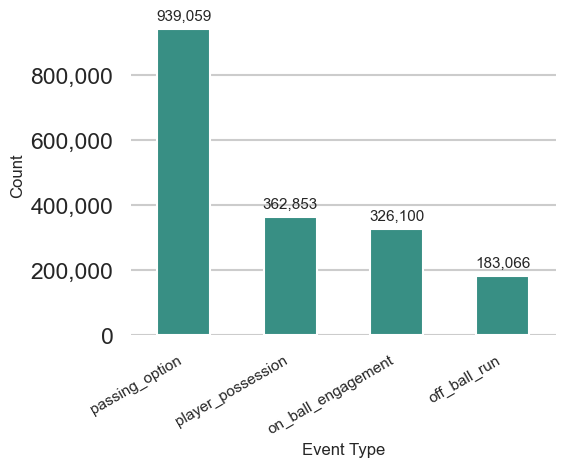

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Style and context
sns.set_style("whitegrid")
sns.set_context("talk")

# Example: top 4 event types (replace with your actual data)
top_events = events["event_type"].value_counts().nlargest(4).index

# Figure size: narrower height, wider width for few bars
plt.figure(figsize=(6, 5))

# Vertical bar plot
ax = sns.countplot(
    data=events,
    x="event_type",
    order=top_events,
    color="#2a9d8f",  # modern teal colour
    width=0.5          # narrower bars for nice spacing
)

# Add counts on top of bars with thousands separator
max_count = events["event_type"].value_counts().max()
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + max_count * 0.02,  # slightly above bar
        f'{int(height):,}',          # thousands separator
        ha='center', va='bottom', fontsize=11
    )

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Labels
ax.set_xlabel("Event Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Rotate x labels slightly if needed
plt.xticks(rotation=30, ha='right', fontsize=11)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Check _player_targeted_xpass_completion_ and _xpass_completion_

In [7]:
# Check missing values per event type
for event_type in ["player_possession", "passing_option"]:
    ev = events[events["event_type"] == event_type]
    total = len(ev)
    non_missing = ev["player_targeted_xpass_completion"].notna().sum()
    print(f"{event_type}: {non_missing}/{total} non-missing ({non_missing/total:.2%})")


# Check missing values per event type
for event_type in ["player_possession", "passing_option"]:
    ev = events[events["event_type"] == event_type]
    total = len(ev)
    non_missing = ev["xpass_completion"].notna().sum()
    print(f"{event_type}: {non_missing}/{total} non-missing ({non_missing/total:.2%})")

player_possession: 306381/362853 non-missing (84.44%)
passing_option: 0/939059 non-missing (0.00%)
player_possession: 0/362853 non-missing (0.00%)
passing_option: 939058/939059 non-missing (100.00%)


In [8]:
events.loc[
    events["event_type"] == "passing_option",
    ["player_name", "event_id", "match_id", "xpass_completion"]
].head(10)

,player_name,event_id,match_id,xpass_completion
3,E. Smith Rowe,7_0,1650385,0.9808
5,K. Tete,7_1,1650385,0.9972
6,I. Diop,7_2,1650385,0.9989
7,Adama Traoré,7_3,1650385,0.6190
9,C. Bassey,7_4,1650385,0.9986
10,K. Tete,7_5,1650385,0.9421
11,Andreas Pereira,7_6,1650385,0.9747
13,Adama Traoré,7_7,1650385,0.4291
14,Rodrigo Muniz,7_8,1650385,0.5103
18,K. Tete,7_9,1650385,0.9211


In [9]:
events.loc[
    events["event_type"] == "passing_option",
    "xpass_completion"
].describe()

count    939058.000000
mean          0.835068
std           0.195455
min           0.011000
25%           0.716700
50%           0.930000
75%           0.989800
max           0.999800
Name: xpass_completion, dtype: float64

In [10]:
import pandas as pd

# Filter player possessions
possessions = events[events["event_type"] == "player_possession"]

# Group by end_type and count xPass presence
summary_df = possessions.groupby('end_type').agg(
    with_xpass=('player_targeted_xpass_completion', lambda x: x.notna().sum()),
    without_xpass=('player_targeted_xpass_completion', lambda x: x.isna().sum())
).reset_index()

# Optional: sort by total count
summary_df['total'] = summary_df['with_xpass'] + summary_df['without_xpass']
summary_df = summary_df.sort_values(by='total', ascending=False).drop(columns='total')

print(summary_df)

          end_type  with_xpass  without_xpass
2             pass      306381          23335
3  possession_loss           0          15666
4             shot           0           8677
1    foul_suffered           0           4200
0        clearance           0           3733
5          unknown           0            861


## Player Passing Analysis

In [12]:
# ==========================================================
# PASSING DECISION & OPTION CREATION ANALYSIS
# xThreat × xPass
# ==========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.2)


# ==========================================================
# 1️⃣ Passing options dataset
# ==========================================================

passing_options = events[
    events["event_type"] == "passing_option"
].copy()


passing_options.head()

,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,duration,period,attacking_side_id,attacking_side,event_type_id,event_type,event_subtype_id,event_subtype,player_id,player_name,player_position_id,player_position,player_in_possession_id,player_in_possession_name,player_in_possession_position_id,player_in_possession_position,team_id,team_shortname,x_start,y_start,channel_id_start,channel_start,third_id_start,third_start,penalty_area_start,x_end,y_end,channel_id_end,channel_end,third_id_end,third_end,penalty_area_end,associated_player_possession_event_id,associated_player_possession_frame_start,associated_player_possession_frame_end,associated_player_possession_end_type_id,associated_player_possession_end_type,associated_off_ball_run_event_id,associated_off_ball_run_subtype_id,associated_off_ball_run_subtype,game_state_id,game_state,team_score,opponent_team_score,phase_index,player_possession_phase_index,first_player_possession_in_team_possession,last_player_possession_in_team_possession,lead_to_different_phase,issued_from_different_phase,n_player_possessions_in_phase,team_possession_loss_in_phase,team_in_possession_phase_type_id,team_in_possession_phase_type,team_out_of_possession_phase_type_id,team_out_of_possession_phase_type,current_team_in_possession_next_phase_type_id,current_team_in_possession_next_phase_type,current_team_out_of_possession_next_phase_type_id,current_team_out_of_possession_next_phase_type,current_team_in_possession_previous_phase_type_id,current_team_in_possession_previous_phase_type,current_team_out_of_possession_previous_phase_type_id,current_team_out_of_possession_previous_phase_type,game_interruption_before_id,game_interruption_before,game_interruption_after_id,game_interruption_after,lead_to_shot,lead_to_goal,distance_covered,trajectory_angle,trajectory_direction_id,trajectory_direction,in_to_out,out_to_in,speed_avg,speed_avg_band_id,speed_avg_band,separation_start,separation_end,separation_gain,last_defensive_line_x_start,last_defensive_line_x_end,delta_to_last_defensive_line_start,delta_to_last_defensive_line_end,delta_to_last_defensive_line_gain,last_defensive_line_height_start,last_defensive_line_height_end,last_defensive_line_height_gain,inside_defensive_shape_start,inside_defensive_shape_end,start_type_id,start_type,end_type_id,end_type,consecutive_on_ball_engagements,one_touch,quick_pass,carry,forward_momentum,is_header,hand_pass,initiate_give_and_go,pass_angle_received,pass_direction_received_id,pass_direction_received,pass_distance_received,pass_range_received_id,pass_range_received,pass_outcome_id,pass_outcome,targeted_passing_option_event_id,high_pass,player_targeted_id,player_targeted_name,player_targeted_position_id,player_targeted_position,player_targeted_x_pass,player_targeted_y_pass,player_targeted_channel_pass_id,player_targeted_channel_pass,player_targeted_third_pass_id,player_targeted_third_pass,player_targeted_penalty_area_pass,player_targeted_x_reception,player_targeted_y_reception,player_targeted_channel_reception_id,player_targeted_channel_reception,player_targeted_third_reception_id,player_targeted_third_reception,player_targeted_penalty_area_reception,player_targeted_distance_to_goal_start,player_targeted_distance_to_goal_end,player_targeted_angle_to_goal_start,player_targeted_angle_to_goal_end,player_targeted_average_speed,player_targeted_speed_avg_band_id,player_targeted_speed_avg_band,speed_difference,player_targeted_xpass_completion,player_targeted_difficult_pass_target,player_targeted_xthreat,player_targeted_dangerous,n_passing_options,n_off_ball_runs,n_passing_options_line_break,n_passing_options_first_line_break,n_passing_options_second_last_line_break,n_passing_options_last_line_break,n_passing_options_ahead,n_passing_options_dangerous_difficult,n_passing_options_dangerous_not_difficult,n_passing_options_not_dangerous_not_difficult,n_passing_options_not_dangerous_difficult,n_passing_options_at_start,n_passi

In [13]:
# ----------------------------------------------------------
# FIX PASSER / RECEIVER IDENTIFIERS
# ----------------------------------------------------------

passing_options["passer_id"] = passing_options["player_in_possession_id"]
passing_options["passer_name"] = passing_options["player_in_possession_name"]

passing_options["receiver_id"] = passing_options["player_id"]
passing_options["receiver_name"] = passing_options["player_name"]


# ==========================================================
# 2️⃣ Pass value
# ==========================================================

passing_options["pass_value"] = (
    passing_options["xthreat"] *
    passing_options["xpass_completion"]
)


# ==========================================================
# 3️⃣ Best option per possession
# ==========================================================

best_option = (
    passing_options
    .groupby(
        ["match_id","associated_player_possession_event_id"],
        as_index=False
    )
    .agg(best_pass_value=("pass_value","max"))
)

passing_options = passing_options.merge(
    best_option,
    on=["match_id","associated_player_possession_event_id"],
    how="left"
)


# ==========================================================
# 4️⃣ Extract executed passes
# ==========================================================

chosen_passes = passing_options[
    passing_options["targeted"] == True
].copy()


# ==========================================================
# 5️⃣ Remove trivial possessions
# ==========================================================

chosen_passes = chosen_passes[
    chosen_passes["best_pass_value"] > 0.0001
].copy()

print("Total analysed decisions:", len(chosen_passes))


# ==========================================================
# 6️⃣ Decision metrics
# ==========================================================

chosen_passes["decision_quality"] = (
    chosen_passes["pass_value"] /
    chosen_passes["best_pass_value"]
)

chosen_passes["chose_best"] = (
    chosen_passes["pass_value"] ==
    chosen_passes["best_pass_value"]
)

chosen_passes["decision_regret"] = (
    chosen_passes["best_pass_value"] -
    chosen_passes["pass_value"]
)


# ==========================================================
# 7️⃣ Pass execution (actual vs expected)
# ==========================================================

chosen_passes["actual_completion"] = (
    chosen_passes["pass_outcome"] == "successful"
).astype(int)


# ==========================================================
# 8️⃣ PASSER METRICS
# ==========================================================

passer_metrics = (
    chosen_passes
    .groupby(["passer_id","passer_name"])
    .agg(
        total_passes=("decision_quality","count"),

        # Decision making
        avg_decision_quality=("decision_quality","mean"),
        chose_best_rate=("chose_best","mean"),
        avg_regret=("decision_regret","mean"),

        # Value
        avg_pass_value=("pass_value","mean"),
        avg_best_option=("best_pass_value","mean"),

        # Execution
        expected_completion=("xpass_completion","mean"),
        actual_completion=("actual_completion","mean")
    )
    .reset_index()
)

passer_metrics["execution_plus_minus"] = (
    passer_metrics["actual_completion"] -
    passer_metrics["expected_completion"]
)


# ==========================================================
# 9️⃣ PASS VALUE PER PLAYER
# ==========================================================

pass_value_total = (
    chosen_passes
    .groupby("passer_id")["pass_value"]
    .sum()
    .reset_index(name="total_pass_value")
)

passer_metrics = passer_metrics.merge(
    pass_value_total,
    on="passer_id",
    how="left"
)


# ==========================================================
# 🔟 OPTION CREATION METRICS (OFF BALL)
# ==========================================================

receiver_metrics = (
    passing_options
    .groupby(["receiver_id","receiver_name"])
    .agg(
        options_available=("pass_value","count"),

        total_option_value=("pass_value","sum"),
        avg_option_value=("pass_value","mean"),

        avg_xthreat_option=("xthreat","mean"),
        avg_xpass_option=("xpass_completion","mean"),

        times_chosen=("targeted","sum")
    )
    .reset_index()
)

receiver_metrics["option_selection_rate"] = (
    receiver_metrics["times_chosen"] /
    receiver_metrics["options_available"]
)

# Option gravity = how attractive the player is as a passing option
receiver_metrics["option_gravity"] = (
    receiver_metrics["avg_option_value"] *
    receiver_metrics["option_selection_rate"]
)


# ==========================================================
# 11️⃣ Minutes played
# ==========================================================

minutes_df = (
    players_match
    .groupby("id")
    .agg(minutes_played=("playing_time_total_minutes_played","sum"))
    .reset_index()
)

minutes_df = minutes_df.rename(columns={"id":"player_id"})


# ==========================================================
# 12️⃣ Per 90 metrics
# ==========================================================

passer_metrics = passer_metrics.merge(
    minutes_df,
    left_on="passer_id",
    right_on="player_id",
    how="left"
)

passer_metrics["passes_per90"] = (
    passer_metrics["total_passes"] /
    passer_metrics["minutes_played"] * 90
)

passer_metrics["pass_value_per90"] = (
    passer_metrics["total_pass_value"] /
    passer_metrics["minutes_played"] * 90
)

passer_metrics["regret_per90"] = (
    passer_metrics["avg_regret"] *
    passer_metrics["passes_per90"]
)

passer_metrics["difficulty_index"] = (
    1 - passer_metrics["expected_completion"]
)

passer_metrics["risk_taken"] = (
    passer_metrics["avg_best_option"] -
    passer_metrics["avg_pass_value"]
)


# Receiver per90 metrics

receiver_metrics = receiver_metrics.merge(
    minutes_df,
    left_on="receiver_id",
    right_on="player_id",
    how="left"
)

receiver_metrics["option_value_per90"] = (
    receiver_metrics["total_option_value"] /
    receiver_metrics["minutes_played"] * 90
)

receiver_metrics["options_per90"] = (
    receiver_metrics["options_available"] /
    receiver_metrics["minutes_played"] * 90
)


# ==========================================================
# 13️⃣ Player positions
# ==========================================================

players_match["player_id"] = players_match["id"]
players_match["player_name"] = players_match["short_name"]
players_match["position"] = players_match["player_role_acronym"]
players_match["position_group"] = players_match["player_role_position_group"]

position_counts = (
    players_match
    .groupby(["player_id","player_name","team_id","position","position_group"])
    .size()
    .reset_index(name="matches_at_position")
)

position_counts_sorted = position_counts.sort_values(
    ["player_id","matches_at_position"],
    ascending=[True,False]
)


def get_main_position(df):

    main_pos = df.iloc[0]["position"]
    pos_group = df.iloc[0]["position_group"]

    if main_pos == "SUB" and len(df) > 1:
        main_pos = df.iloc[1]["position"]
        pos_group = df.iloc[1]["position_group"]

    if main_pos == "GK":
        pos_group = "Goalkeeper"

    return pd.Series({
        "main_position": main_pos,
        "position_group": pos_group
    })


main_positions = (
    position_counts_sorted
    .groupby("player_id")
    .apply(get_main_position)
    .reset_index()
)


# ==========================================================
# 14️⃣ Team lookup
# ==========================================================

player_team = (
    position_counts
    .sort_values("matches_at_position",ascending=False)
    .drop_duplicates("player_id")
)[["player_id","team_id"]]

team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(
        columns={"home_team_id":"team_id","home_team_name":"team_name"}
    ),
    matches[["away_team_id","away_team_name"]].rename(
        columns={"away_team_id":"team_id","away_team_name":"team_name"}
    )
]).drop_duplicates()


# ==========================================================
# 15️⃣ Merge player info
# ==========================================================

player_info = (
    main_positions
    .merge(player_team,on="player_id",how="left")
    .merge(team_lookup,on="team_id",how="left")
)

passer_metrics = passer_metrics.merge(
    player_info,
    left_on="passer_id",
    right_on="player_id",
    how="left"
)

receiver_metrics = receiver_metrics.merge(
    player_info,
    left_on="receiver_id",
    right_on="player_id",
    how="left"
)


# ==========================================================
# 16️⃣ Filter reliable players
# ==========================================================

passers_filtered = passer_metrics[
    (passer_metrics["total_passes"] >= 200) &
    (passer_metrics["minutes_played"] >= 900)
].copy()

receivers_filtered = receiver_metrics[
    (receiver_metrics["options_available"] >= 200) &
    (receiver_metrics["minutes_played"] >= 900)
].copy()

print("Passers analysed:", len(passers_filtered))
print("Receivers analysed:", len(receivers_filtered))


# ==========================================================
# 17️⃣ Rankings
# ==========================================================

print("\nBest Decision Makers")
print(
    passers_filtered
    .sort_values("avg_decision_quality",ascending=False)
    [["passer_name","team_name","main_position",
      "avg_decision_quality","chose_best_rate"]]
    .head(15)
)

print("\nBest Pass Execution")
print(
    passers_filtered
    .sort_values("execution_plus_minus",ascending=False)
    [["passer_name","team_name","main_position",
      "execution_plus_minus"]]
    .head(15)
)

print("\nMost Valuable Passers (xT×xPass per90)")
print(
    passers_filtered
    .sort_values("pass_value_per90",ascending=False)
    [["passer_name","team_name","main_position",
      "pass_value_per90"]]
    .head(15)
)

print("\nBest Passing Options Creators")
print(
    receivers_filtered
    .sort_values("option_value_per90",ascending=False)
    [["receiver_name","team_name","main_position",
      "option_value_per90"]]
    .head(15)
)


# ==========================================================
# 18️⃣ VISUALISATIONS
# ==========================================================

# Passing intelligence map
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=passers_filtered,
    x="difficulty_index",
    y="execution_plus_minus",
    size="pass_value_per90",
    hue="avg_decision_quality",
    alpha=0.85
)

plt.xlabel("Pass Difficulty")
plt.ylabel("Execution vs Expected")
plt.title("Passing Skill Map")

plt.tight_layout()
plt.show()


# Decision vs execution
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=passers_filtered,
    x="avg_decision_quality",
    y="execution_plus_minus",
    hue="position_group",
    alpha=0.85
)

plt.xlabel("Decision Quality")
plt.ylabel("Execution vs Expected")
plt.title("Decision Making vs Pass Execution")

plt.tight_layout()
plt.show()


# Option creation map
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=receivers_filtered,
    x="options_per90",
    y="option_value_per90",
    hue="position_group",
    alpha=0.85
)

plt.xlabel("Passing Options per 90")
plt.ylabel("Option Value per 90")
plt.title("Off-ball Passing Option Creation")

plt.tight_layout()
plt.show()

Total analysed decisions: 291724


NameError: name 'players_match' is not defined